# 🧪 Experiment No. 5
# Support Vector Machine (SVM) for Classification

### Machine Learning Laboratory

**Algorithm:** Support Vector Machine (SVM)  
**Dataset:** Iris Dataset  
**Programming Language:** Python  
**Library:** Scikit-learn  
**Platform:** Jupyter Notebook

# 🎯 Aim

To practically implement and understand the fundamental concepts of the **Support Vector Machine (SVM)** algorithm, a powerful supervised machine learning algorithm for classification, through hands-on coding and data analysis.

# 🎯 Objectives

1. To comprehend the **theoretical foundation and intuition behind SVM**.

2. To understand how SVM uses **hyperplanes and support vectors** for classification.

3. To gain practical experience in implementing SVM using **Python and Scikit-learn**.

4. To learn how to **preprocess data**, train an SVM classifier, and evaluate its performance.

5. To understand important evaluation metrics such as:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-Score**
   - **Confusion Matrix**

6. To understand the role of **kernel functions** in handling linearly and non-linearly separable data.

7. To understand the effect of important SVM hyperparameters such as:
   - **C**
   - **Gamma**
   - **Kernel**

8. To perform **hyperparameter tuning using GridSearchCV**.

# 📌 Relevance

Support Vector Machines are widely used for classification problems because they can provide robust performance, particularly in high-dimensional feature spaces.

### Important applications of SVM include:

- Image classification
- Text classification
- Handwritten digit recognition
- Bioinformatics
- Face detection
- Medical classification
- Spam detection

### Types of SVM

**Linear SVM:**  
Separates classes using a linear decision boundary or hyperplane.

**Non-Linear SVM:**  
Uses kernel functions to transform the input data into a higher-dimensional feature space so that classes can be separated more effectively.

Common kernels include:

- **Linear**
- **Polynomial**
- **RBF (Radial Basis Function)**
- **Sigmoid**

# 📚 Theory — Support Vector Machine

## What is Support Vector Machine?

**Support Vector Machine (SVM)** is a supervised machine learning algorithm mainly used for **classification** and sometimes for regression.

The main objective of SVM is to find the **optimal hyperplane** that separates data points belonging to different classes.

The optimal hyperplane is selected such that the **margin between the classes is maximized**.

---

## Basic Idea

Suppose we have two classes of data.

SVM tries to find a decision boundary that separates the two classes.

The points closest to the decision boundary are called **Support Vectors**.

The distance between the decision boundary and the closest support vectors is called the **Margin**.

SVM attempts to maximize this margin.

### In simple terms:

**SVM = Find the best separating boundary with the maximum possible margin.**

# 📐 Hyperplane

A **hyperplane** is a decision boundary that separates different classes.

For a two-dimensional dataset, the hyperplane is represented by a straight line:

$$
w \cdot x + b = 0
$$

Where:

- **w** = weight vector
- **x** = input feature vector
- **b** = bias/intercept

For higher-dimensional data, the decision boundary becomes a plane or hyperplane.

### Decision Rule

$$
f(x) = sign(w \cdot x + b)
$$

If:

$$
f(x) > 0
$$

the sample belongs to one class.

If:

$$
f(x) < 0
$$

the sample belongs to the other class.

# 🔴 Support Vectors

**Support vectors** are the training data points that are closest to the decision boundary.

They are extremely important because they determine the position and orientation of the optimal hyperplane.

If the support vectors change significantly, the position of the decision boundary can also change.

### Important Point

Not every training data point becomes a support vector.

Only the important boundary points that influence the decision boundary are called **support vectors**.

# ↔️ Margin

The **margin** is the distance between the decision boundary and the closest data points from each class.

SVM attempts to find a hyperplane that **maximizes this margin**.

A larger margin generally provides better separation between classes and can improve generalization on unseen data.

### SVM Objective

The basic idea is:

**Maximize the margin while correctly classifying the training data as much as possible.**

# 🟢 Hard Margin and Soft Margin

## Hard Margin SVM

Hard Margin SVM requires that all training samples are perfectly separated.

It works well when:

- Data is perfectly linearly separable.
- There are very few or no outliers.

However, real-world datasets often contain noise and overlapping classes.

---

## Soft Margin SVM

Soft Margin SVM allows some samples to violate the margin or even be misclassified.

This makes SVM more practical for real-world datasets.

The **C parameter** controls the trade-off between:

- Maximizing the margin
- Penalizing classification errors

# ⚙️ C Parameter

**C** is the regularization parameter of SVM.

It controls how strongly the model penalizes misclassification.

### Low C

A lower value of **C** allows more classification errors but generally creates a wider margin.

### High C

A higher value of **C** penalizes errors more strongly and attempts to classify training samples more strictly.

Therefore:

**Small C → wider margin, more tolerance**

**Large C → narrower margin, less tolerance**

# 🔷 Types of Support Vector Machine

## 1. Linear SVM

Linear SVM is used when the classes can be separated approximately using a straight line or hyperplane.

Example:

```text
Class A      |      Class B
● ● ●        |       ○ ○ ○
● ● ●        |       ○ ○ ○
             ↑
       Decision Boundary


---

## Markdown Cell — Algorithm

```markdown
# 🔢 Steps of SVM Algorithm

1. **Collect the dataset**
2. **Clean the data**
3. **Perform exploratory data analysis**
4. **Separate features and target**
5. **Split the dataset into training and testing sets**
6. **Scale the features**
7. **Select an appropriate SVM kernel**
8. **Train the SVM model**
9. **Find the support vectors**
10. **Make predictions**
11. **Evaluate the model**
12. **Tune hyperparameters**
13. **Compare different kernels**
14. **Test the final model on new data**

# Step 1 - Import Required Libraries

In this step, we import all the Python libraries required for data processing, visualization, model building, and evaluation.

### Libraries used:

- **Pandas** → Data manipulation
- **NumPy** → Numerical calculations
- **Matplotlib** → Data visualization
- **Seaborn** → Statistical visualization
- **Scikit-learn** → Machine learning algorithms and evaluation

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


# Step 2 - Load the Iris Dataset

The **Iris dataset** is a commonly used classification dataset.

It contains measurements of iris flowers belonging to three species:

- **Iris-setosa**
- **Iris-versicolor**
- **Iris-virginica**

The dataset contains four numerical features:

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

The target variable is the flower species.

In [18]:
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

data = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Step 3 - Display the First Five Records

The `head()` function displays the first five rows of the dataset.

This helps us understand the structure and format of the data.

In [19]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Step 4 - Display Dataset Information

The `info()` function provides information about:

- Number of rows
- Number of columns
- Column names
- Data types
- Non-null values

This is useful during the initial data inspection.

In [20]:
    data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# Step 5 - Check Dataset Shape

The `shape` attribute returns:

**(number of rows, number of columns)**

This tells us how many samples and variables are present in the dataset.

In [21]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 150
Number of columns: 5


# Step 6 - Check Missing Values

Missing values can cause problems during model training.

Therefore, we check every column for missing values before building the model.

In [22]:
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# Step 7 - Check Duplicate Records

Duplicate observations may affect the analysis.

We calculate the number of duplicate rows in the dataset.

In [23]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 3


# Step 8 - Generate Statistical Summary

The `describe()` function provides statistical information about numerical features.

It includes:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [24]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Step 9 - Check Target Class Distribution

We check how many samples belong to each species.

This helps us understand whether the classes are balanced.

In [25]:
print("Class distribution:")
print(data["species"].value_counts())

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Step 10 - Visualize Class Distribution

A count plot is used to visualize the number of samples belonging to each class.

This makes it easier to identify whether one class has significantly more samples than another.

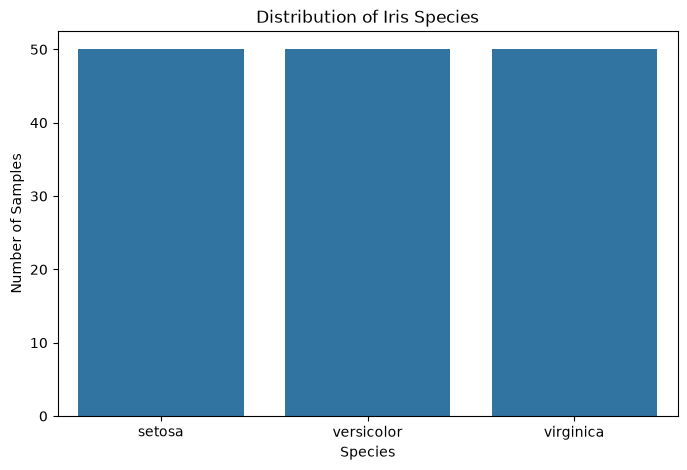

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.show()

# Step 11 - Visualize Feature Relationships

A pair plot is used to visualize relationships between different numerical features.

It can help us identify whether the classes are naturally separable.

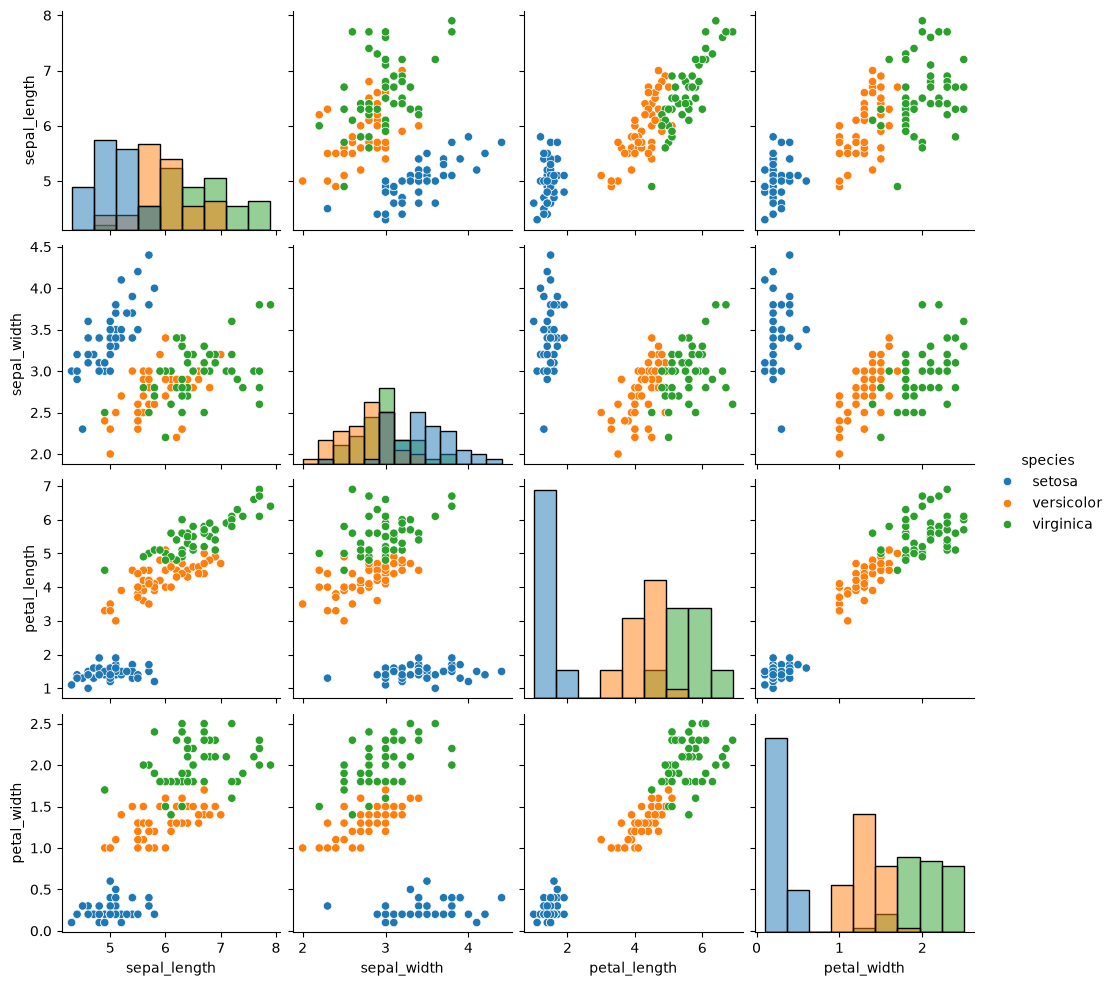

In [27]:
sns.pairplot(
    data,
    hue="species",
    diag_kind="hist"
)

plt.show()

# Step 12 - Create Correlation Matrix

Correlation shows the relationship between numerical variables.

A heatmap makes these relationships easier to understand visually.

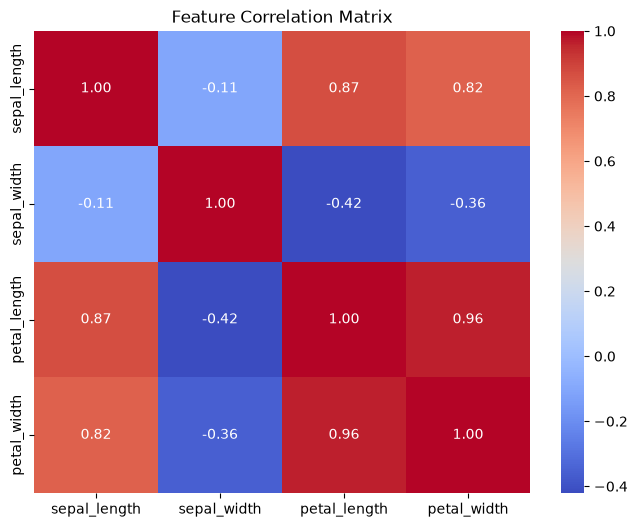

In [28]:
numeric_data = data.drop(columns=["species"])

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

# Step 13 - Separate Features and Target

The independent variables are stored in **X**.

The dependent variable or target is stored in **y**.

### X

Contains the four flower measurements.

### y

Contains the flower species.

In [29]:
X = data.drop(columns=["species"])
y = data["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


# Step 14 - Display Feature Names

We display the names of all input features.

These features will be used by the SVM classifier to predict the flower species.

In [30]:
print("Feature names:")
for feature in X.columns:
    print("-", feature)

Feature names:
- sepal_length
- sepal_width
- petal_length
- petal_width


# Step 15 - Split Dataset into Training and Testing Sets

The dataset is divided into:

- **80% training data**
- **20% testing data**

The training data is used to learn the model.

The testing data is used to evaluate how well the trained model performs on unseen data.

`stratify=y` ensures that the class proportions are maintained in both sets.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# Step 16 - Feature Scaling

SVM is sensitive to the scale of input features.

For example, if one feature has values between 0 and 1 while another has values between 100 and 1000, the larger feature can have an unwanted influence.

Therefore, we use **StandardScaler**.

Standardization approximately transforms each feature to:

- Mean = 0
- Standard deviation = 1

### Important

The scaler is fitted only on the training data.

The same transformation is then applied to the testing data.

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Step 17 - Train Linear SVM

A **Linear SVM** attempts to separate the classes using a linear decision boundary.

Here, `C=1.0` is the regularization parameter.

In [33]:
linear_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

print("Linear SVM training completed.")

Linear SVM training completed.


# Step 18 - Make Predictions using Linear SVM

The trained Linear SVM model is used to predict the classes of the unseen testing samples.

In [34]:
y_pred_linear = linear_svm.predict(X_test_scaled)

print("Predictions:")
print(y_pred_linear)

Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


# Step 19 - Calculate Linear SVM Accuracy

Accuracy represents the proportion of correctly classified samples.

$$
Accuracy = \frac{Correct\ Predictions}{Total\ Predictions}
$$

In [35]:
linear_accuracy = accuracy_score(
    y_test,
    y_pred_linear
)

print(
    "Linear SVM Accuracy:",
    round(linear_accuracy * 100, 2),
    "%"
)

Linear SVM Accuracy: 100.0 %


# Step 20 - Train RBF Kernel SVM

The **RBF (Radial Basis Function)** kernel is a non-linear kernel.

It is useful when classes cannot be effectively separated using a simple straight-line boundary.

Here:

- `C=1.0` controls regularization.
- `gamma="scale"` automatically determines a suitable gamma value based on the training data.

In [36]:
rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

print("RBF SVM training completed.")

RBF SVM training completed.


# Step 21 - Make Predictions using RBF SVM

The RBF SVM model is used to predict the classes of the testing samples.

In [37]:
y_pred_rbf = rbf_svm.predict(X_test_scaled)

print("RBF SVM Predictions:")
print(y_pred_rbf)

RBF SVM Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


# Step 22 - Evaluate RBF SVM

We calculate several important classification metrics:

### Accuracy
Percentage of correctly classified samples.

### Precision
Measures how many predicted positive/class samples are actually correct.

### Recall
Measures how many actual samples of a class were correctly identified.

### F1-Score
Harmonic mean of precision and recall.

In [38]:
print("RBF SVM Evaluation")
print("=" * 40)

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred_rbf), 4)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_rbf,
            average="weighted"
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred_rbf,
            average="weighted"
        ),
        4
    )
)

print(
    "F1-Score:",
    round(
        f1_score(
            y_test,
            y_pred_rbf,
            average="weighted"
        ),
        4
    )
)

RBF SVM Evaluation
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666


# Step 23 - Generate Classification Report

The classification report provides:

- **Precision**
- **Recall**
- **F1-score**
- **Support**

for every Iris species separately.

In [39]:
print(
    classification_report(
        y_test,
        y_pred_rbf
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Step 24 - Generate Confusion Matrix

A **confusion matrix** shows the number of correct and incorrect predictions for each class.

For a multi-class classification problem:

- Rows represent actual classes.
- Columns represent predicted classes.

The diagonal values represent correctly classified samples.

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred_rbf
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


# Step 25 - Visualize Confusion Matrix

A heatmap is used to visualize the confusion matrix.

A darker/larger diagonal value indicates correctly classified samples.

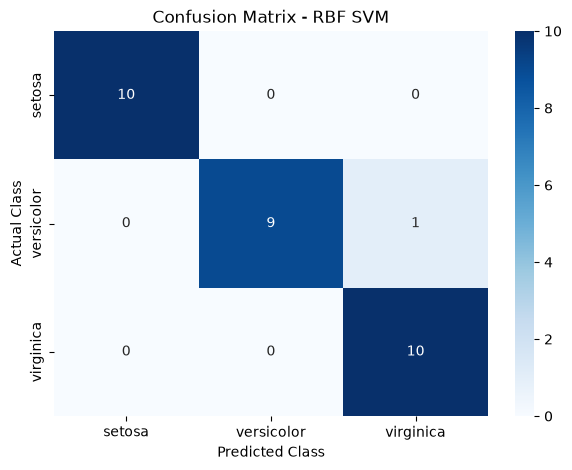

In [41]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rbf_svm.classes_,
    yticklabels=rbf_svm.classes_
)

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# Step 26 - Find Support Vectors

One of the important concepts of SVM is the **support vector**.

The `support_vectors_` attribute gives the actual training samples that act as support vectors.

The `n_support_` attribute shows the number of support vectors for each class.

In [42]:
print("Number of support vectors for each class:")

for class_name, count in zip(
    rbf_svm.classes_,
    rbf_svm.n_support_
):
    print(class_name, ":", count)

print(
    "\nTotal support vectors:",
    len(rbf_svm.support_vectors_)
)

Number of support vectors for each class:
setosa : 10
versicolor : 18
virginica : 19

Total support vectors: 47


# Step 27 - Compare Different Kernels

SVM provides different kernel functions.

In this step, we train models using:

- **Linear kernel**
- **Polynomial kernel**
- **RBF kernel**
- **Sigmoid kernel**

This demonstrates how the kernel selection can affect model performance.

In [43]:
kernels = [
    "linear",
    "poly",
    "rbf",
    "sigmoid"
]

kernel_results = {}

for kernel in kernels:
    model = SVC(
        kernel=kernel,
        C=1.0,
        gamma="scale"
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    kernel_results[kernel] = accuracy

print("Kernel Performance:")

for kernel, accuracy in kernel_results.items():
    print(
        f"{kernel}: {accuracy * 100:.2f}%"
    )

Kernel Performance:
linear: 100.00%
poly: 90.00%
rbf: 96.67%
sigmoid: 90.00%


# Step 28 - Hyperparameter Tuning using GridSearchCV

SVM performance can depend on hyperparameters.

Important hyperparameters include:

- **C**
- **Gamma**
- **Kernel**

`GridSearchCV` tests different combinations of these values using cross-validation.

This allows us to systematically search for a suitable parameter combination rather than manually guessing.

In [44]:
parameter_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["linear", "rbf", "poly"]
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "\nBest Cross-Validation Accuracy:",
    round(grid_search.best_score_, 4)
)

Best Parameters:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best Cross-Validation Accuracy: 0.9833


# Step 29 - Evaluate the Optimized SVM Model

The best model found by `GridSearchCV` is evaluated on the testing dataset.

The testing data was not used during the hyperparameter search, so it provides an independent evaluation of the final model.

In [45]:
best_svm = grid_search.best_estimator_

y_pred_best = best_svm.predict(
    X_test_scaled
)

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print(
    "Optimized SVM Test Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best
    )
)

Optimized SVM Test Accuracy: 96.67 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Step 30 - Predict a New Iris Flower

Finally, we use the optimized SVM model to classify a completely new flower sample.

The sample contains:

- Sepal Length = 5.1
- Sepal Width = 3.5
- Petal Length = 1.4
- Petal Width = 0.2

The sample must be scaled using the **same scaler** that was fitted on the training data.

The trained SVM model then predicts the species.

In [46]:
# Step 30 - Predict a New Iris Flower

new_sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

# Scale the new sample
new_sample_scaled = scaler.transform(new_sample)

# Predict the species
prediction = best_svm.predict(new_sample_scaled)

print("New Sample:")
print(new_sample)

print("\nPredicted Species:")
print(prediction[0])

New Sample:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Species:
setosa


# 📈 Kernel Comparison

The performance of different SVM kernels can be compared using the results obtained during the experiment.

| Kernel | Test Accuracy |
|---|---:|
| Linear | Obtained from Step 27 |
| Polynomial | Obtained from Step 27 |
| RBF | Obtained from Step 27 |
| Sigmoid | Obtained from Step 27 |

The exact values depend on the train-test split and parameter settings used during execution.

# 📊 Final Results

The Support Vector Machine algorithm was successfully implemented on the Iris dataset.

The experiment included:

- Dataset loading
- Data inspection
- Missing-value checking
- Duplicate checking
- Exploratory Data Analysis
- Feature-target separation
- Train-test splitting
- Feature standardization
- Linear SVM
- RBF Kernel SVM
- Polynomial Kernel SVM
- Sigmoid Kernel SVM
- Accuracy calculation
- Precision calculation
- Recall calculation
- F1-score calculation
- Confusion matrix
- Support vector identification
- Hyperparameter tuning using GridSearchCV
- Prediction of a new sample

The final model parameters were selected using **GridSearchCV with 5-fold cross-validation**.

# ✅ Conclusion

In this experiment, the **Support Vector Machine (SVM)** classification algorithm was successfully implemented using Python and Scikit-learn on the Iris dataset.

The experiment provided practical understanding of important SVM concepts including:

- **Hyperplane**
- **Support Vectors**
- **Margin**
- **Hard Margin**
- **Soft Margin**
- **Kernel Functions**
- **C Parameter**
- **Gamma Parameter**
- **Feature Scaling**
- **Classification Metrics**

Different SVM kernels including **Linear, Polynomial, RBF, and Sigmoid** were explored.

The model was evaluated using **accuracy, precision, recall, F1-score, confusion matrix, and classification report**.

Hyperparameter optimization was also performed using **GridSearchCV with cross-validation**.

Finally, the optimized SVM model was used to classify a new Iris flower sample.

Therefore, the experiment demonstrates how SVM can be effectively used for **supervised classification problems** and how appropriate preprocessing, kernel selection, and hyperparameter tuning can influence model performance.